# Лабораторная работа 3. Оптимизация, регуляризация и робастность нейросети

**Курс:** Машинное обучение. Безопасность ИИ-систем

**Формат:** индивидуально

**Среда:** Python, PyTorch

**По материалам Лекции 2.1 и Лекции 2.2**

## Цель работы
Экспериментально проверить, как выбор оптимизатора и методов регуляризации влияет на сходимость, переобучение, обобщение и чувствительность модели к возмущениям входа.

## Результаты обучения
После выполнения работы вы должны уметь:
- объяснять идею прямого прохода и backpropagation через цепное правило;
- различать SGD, Momentum и Adam с точки зрения траектории оптимизации и свойств найденного минимума;
- применять L2-регуляризацию, Dropout, BatchNorm и early stopping;
- оценивать train/test gap как признак переобучения;
- связывать переобучение и уязвимость модели к малым возмущениям входа.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.


## 0. Подготовка окружения

In [ ]:
# TODO: импортируйте необходимые библиотеки
import copy
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 1. Данные

**Задание:** загрузите датасет для классификации изображений.
Рекомендуется MNIST или Fashion-MNIST (через `torchvision.datasets`).


In [ ]:
# TODO: загрузите датасет (например, torchvision.datasets.MNIST)
# TODO: создайте train/val/test DataLoader-ы

from torchvision import datasets, transforms

transform = transforms.Compose([transforms.ToTensor()])

full_train = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

N_TRAIN, N_VAL = 10_000, 2_000
gen = torch.Generator().manual_seed(RANDOM_STATE)
perm = torch.randperm(len(full_train), generator=gen).tolist()

train_dataset = Subset(full_train, perm[:N_TRAIN])
val_dataset   = Subset(full_train, perm[N_TRAIN:N_TRAIN + N_VAL])

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=512, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=512, shuffle=False)

print(f"train: {len(train_dataset)} | val: {len(val_dataset)} | test: {len(test_dataset)}")
print("размер изображения:", train_dataset[0][0].shape, "| число классов: 10")


train: 10000 | val: 2000 | test: 10000
размер изображения: torch.Size([1, 28, 28]) | число классов: 10


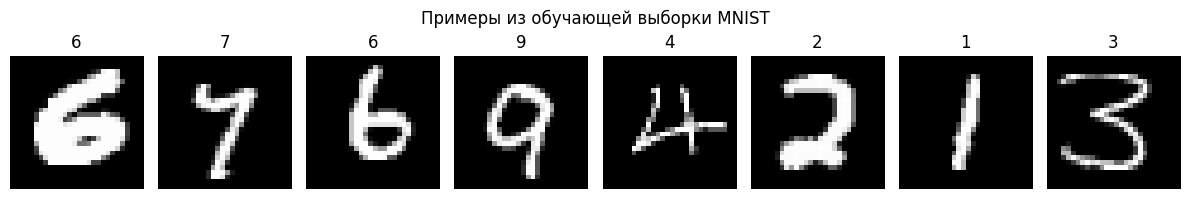

In [ ]:
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, idx in zip(axes, range(8)):
    img, lbl = train_dataset[idx]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(str(lbl))
    ax.axis("off")
plt.suptitle("Примеры из обучающей выборки MNIST")
plt.tight_layout()
plt.show()

## 2. Формализм прямого прохода и backpropagation

**Задание:** опишите (в markdown, формулами) прямой проход для вашей архитектуры и кратко распишите, как вычисляется ошибка слоя \( \delta^{(l)} \) через цепное правило.

**Вопрос для отчёта:** почему backpropagation имеет вычислительную сложность \(O(P)\) по числу параметров, а не \(O(2P)\), как при наивном численном дифференцировании?


## Формализм прямого прохода и backpropagation

### Прямой проход

Рассмотрим сеть с $L$ слоями. Вход сети — развёрнутая в вектор картинка $a^{(0)} = x$. Для слоя $l = 1, \dots, L$ прямой проход задаётся парой уравнений:

$$z^{(l)} = W^{(l)} a^{(l-1)} + b^{(l)}, \qquad a^{(l)} = f\big(z^{(l)}\big),$$

где $W^{(l)}$ и $b^{(l)}$ — матрица весов и вектор смещений слоя $l$, $f$ — функция активации (ReLU, sigmoid, tanh и др.), $z^{(l)}$ — предактивации, $a^{(l)}$ — активации. Выход сети $a^{(L)}$ и есть предсказание.

В нашей конфигурации $L = 3$, размерности $784 \to 256 \to 128 \to 10$; на скрытых слоях $f = \mathrm{ReLU}$, на выходном — softmax.

Функция потерь $L\big(a^{(L)}, y\big)$ сравнивает предсказание с истинной меткой. Для классификации используется кросс-энтропия:

$$L = -\sum_c y_c \log a_c^{(L)}.$$

Цель обучения — минимизировать $L$ по параметрам $\theta = \{W^{(l)}, b^{(l)}\}$.

> **По реализации.** В коде softmax отдельным слоем не ставится: из сети выходят логиты $z^{(L)}$, которые подаются напрямую в `CrossEntropyLoss`, а она внутри применяет `log_softmax`. Численно это то же самое, но устойчивее: раздельное вычисление $\exp$ и затем $\log$ переполняется на больших логитах, тогда как объединённая формула считается через вычитание максимума.

### Обратный проход

Backpropagation основан на цепном правиле дифференцирования. Введём «ошибку слоя» — производную потерь по предактивациям:

$$\delta^{(l)} = \frac{\partial L}{\partial z^{(l)}}.$$

Содержательно $\delta^{(l)}$ показывает, насколько изменится функция потерь, если сдвинуть вход нелинейности на слое $l$. Вычисление идёт от выхода к входу.

**Выходной слой.** Ошибка получается умножением градиента потерь по активациям на производную функции активации:

$$\delta^{(L)} = \nabla_{a^{(L)}} L \odot f'\big(z^{(L)}\big),$$

где $\odot$ — покомпонентное произведение (произведение Адамара). Формула общая и работает для любой пары «активация — функция потерь». Для softmax с кросс-энтропией она сворачивается к особенно простому виду $\delta^{(L)} = a^{(L)} - y$: ошибка на выходе есть разность предсказанного и истинного распределений. Именно поэтому softmax и кросс-энтропию объединяют в один вычислительный блок.

**Скрытые слои.** Ошибка распространяется назад через транспонированную матрицу весов следующего слоя и домножается на производную активации текущего:

$$\delta^{(l)} = \Big(\big(W^{(l+1)}\big)^{\!\top} \delta^{(l+1)}\Big) \odot f'\big(z^{(l)}\big).$$

Для ReLU производная равна индикатору $\mathbb{1}\big[z^{(l)} > 0\big]$, то есть ошибка гасится на тех нейронах, которые на прямом проходе были неактивны и на результат не влияли.

**Градиенты по параметрам.** Из вычисленных $\delta^{(l)}$ они получаются напрямую, без дополнительных вычислений:

$$\frac{\partial L}{\partial W^{(l)}} = \delta^{(l)} \big(a^{(l-1)}\big)^{\!\top}, \qquad \frac{\partial L}{\partial b^{(l)}} = \delta^{(l)}.$$

Первое выражение — внешнее произведение: одна операция даёт градиент сразу по всей матрице весов. Используемая в нём активация $a^{(l-1)}$ берётся готовой, сохранённой на прямом проходе.

### Почему сложность $O(P)$, а не $O(P^2)$

Численное дифференцирование оценивает каждую производную независимо: чтобы получить $\partial L / \partial \theta_i$ центральной разностью, нужно два прямых прохода — $L(\theta + h e_i)$ и $L(\theta - h e_i)$. Отсюда запись «$O(2P)$»: два прохода **на каждый** из $P$ параметров. Но один прямой проход сам стоит $O(P)$ операций, поэтому полный градиент обходится в $2P \cdot O(P) = O(P^2)$ — квадратично по числу параметров.

Backpropagation даёт тот же результат за один прямой и один обратный проход. Выигрыш обеспечивает переиспользование промежуточных величин: $\delta^{(l)}$ вычисляется один раз на слой и обслуживает все его параметры сразу, а активации $a^{(l-1)}$ не пересчитываются, а берутся из прямого прохода. По существу это динамическое программирование на вычислительном графе — каждое промежуточное значение считается однократно. Обратный проход по числу операций сопоставим с прямым, поэтому полный градиент стоит $O(P)$ на все параметры вместе, а не на каждый.

Платой является память: активации всех слоёв приходится хранить до момента, когда до них дойдёт обратный проход.

## 3. Базовая архитектура сети

In [ ]:
# TODO: определите класс простого MLP (2-3 полносвязных слоя)
# Параметризуйте модель так, чтобы можно было легко включать/выключать dropout и batchnorm

class SimpleMLP(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=256, num_classes=10,
                 use_dropout=False, use_batchnorm=False, dropout_p=0.5):
        super().__init__()
        self.input_dim = input_dim
        dims = [input_dim, hidden_dim, hidden_dim // 2]

        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(dims[i + 1]))
            layers.append(nn.ReLU())
            if use_dropout:
                layers.append(nn.Dropout(dropout_p))
        layers.append(nn.Linear(dims[-1], num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x.view(x.size(0), -1))

_m = SimpleMLP()
print(_m)
print("выход:", _m(torch.randn(4, 1, 28, 28)).shape)
print("число параметров:", sum(p.numel() for p in _m.parameters()))


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
выход: torch.Size([4, 10])
число параметров: 235146


In [ ]:
# TODO: напишите универсальные функции train_epoch(model, loader, optimizer, criterion, device)
# и evaluate(model, loader, criterion, device), возвращающие loss и accuracy

def train_epoch(model, loader, optimizer, criterion, device):
    """Одна эпоха обучения. Возвращает (loss, accuracy) по обучающей выборке."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Оценка модели без обновления весов. Возвращает (loss, accuracy)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y)

        total_loss += loss.item() * y.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total


## 4. Серия A. Сравнение оптимизаторов

**Задание:** обучите одну и ту же архитектуру (без дополнительной регуляризации) со следующими оптимизаторами:
- SGD;
- SGD + Momentum (momentum=0.9);
- Adam.

Для каждого варианта зафиксируйте одинаковое число эпох и одинаковый learning rate (или обоснуйте отличие).


In [ ]:
def build_optimizer(model, name, lr, weight_decay=0.0):
    if name == "sgd":
        return optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    if name == "sgd_momentum":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    if name == "adam":
        return optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    raise ValueError(name)


def run_experiment(name, opt_name, lr, epochs=15, weight_decay=0.0,
                   use_dropout=False, use_batchnorm=False,
                   early_stopping=False, patience=3,
                   loader=None, seed=RANDOM_STATE, verbose=True):
    """Универсальный прогон: создаёт модель с фиксированным seed, обучает, пишет историю."""
    loader = train_loader if loader is None else loader

    torch.manual_seed(seed)          # одинаковая инициализация весов во всех экспериментах
    np.random.seed(seed)
    model = SimpleMLP(use_dropout=use_dropout, use_batchnorm=use_batchnorm).to(device)

    optimizer = build_optimizer(model, opt_name, lr, weight_decay)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": [],
               "val_loss": [], "val_acc": []}

    best_val, best_state, wait, best_epoch = float("inf"), None, 0, 0
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)

        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)
        history["test_loss"].append(te_loss);  history["test_acc"].append(te_acc)

        if early_stopping:
            if va_loss < best_val - 1e-4:
                best_val, best_state, wait, best_epoch = va_loss, copy.deepcopy(model.state_dict()), 0, epoch
            else:
                wait += 1
                if wait >= patience:
                    if verbose:
                        print(f"  early stopping на эпохе {epoch} (лучшая эпоха: {best_epoch})")
                    model.load_state_dict(best_state)
                    break

    if verbose:
        print(f"[{name}] эпох: {len(history['train_loss'])} | время: {time.time() - t0:.1f} c | "
              f"train_acc={history['train_acc'][-1]:.4f} test_acc={history['test_acc'][-1]:.4f} "
              f"gap={history['train_acc'][-1] - history['test_acc'][-1]:.4f}")
    return model, history


EPOCHS = 15

готово


In [ ]:
# TODO: обучите модель с оптимизатором SGD
# Сохраните историю train/test loss и accuracy по эпохам
model_sgd, history_sgd = run_experiment("SGD", "sgd", lr=0.01, epochs=EPOCHS)


[SGD] эпох: 15 | время: 53.7 c | train_acc=0.8484 test_acc=0.8535 gap=-0.0051


In [ ]:
# TODO: обучите модель с оптимизатором SGD + Momentum
model_sgd_momentum, history_sgd_momentum = run_experiment(
    "SGD+Momentum", "sgd_momentum", lr=0.01, epochs=EPOCHS)


[SGD+Momentum] эпох: 15 | время: 46.6 c | train_acc=0.9543 test_acc=0.9330 gap=0.0213


In [ ]:
# TODO: обучите модель с оптимизатором Adam
model_adam, history_adam = run_experiment("Adam", "adam", lr=0.001, epochs=EPOCHS)


[Adam] эпох: 15 | время: 49.8 c | train_acc=0.9972 test_acc=0.9561 gap=0.0411


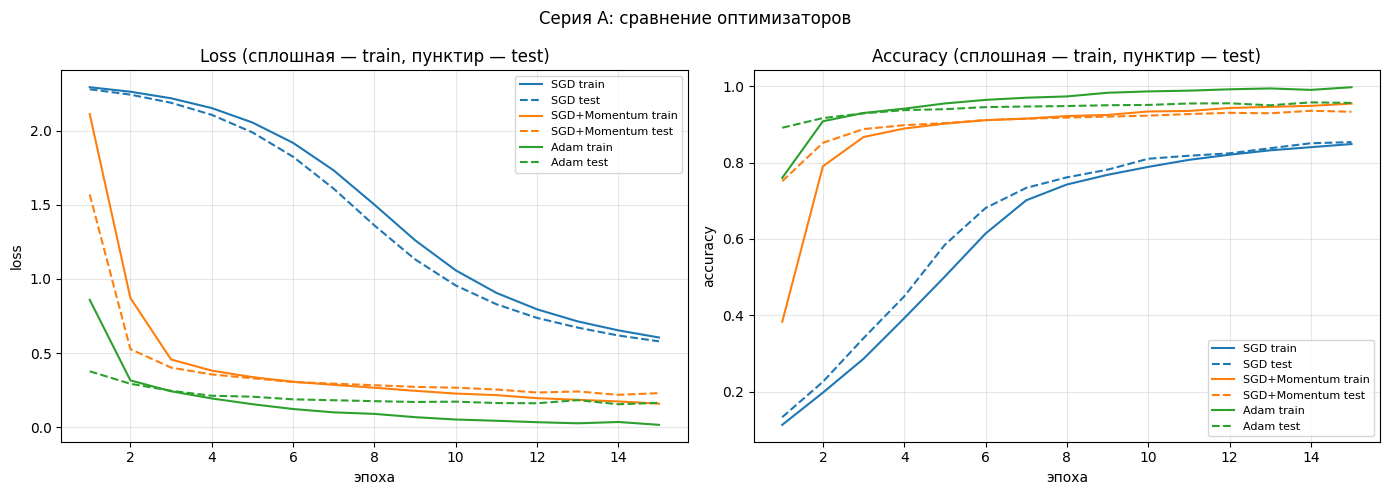

In [ ]:
# TODO: постройте графики train/test loss и train/test accuracy для всех трёх оптимизаторов
# Используйте единый график с несколькими линиями для удобного сравнения
histories_A = {
    "SGD": history_sgd,
    "SGD+Momentum": history_sgd_momentum,
    "Adam": history_adam,
}
colors = {"SGD": "tab:blue", "SGD+Momentum": "tab:orange", "Adam": "tab:green"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in histories_A.items():
    ep = range(1, len(h["train_loss"]) + 1)
    axes[0].plot(ep, h["train_loss"], color=colors[name], label=f"{name} train")
    axes[0].plot(ep, h["test_loss"],  color=colors[name], ls="--", label=f"{name} test")
    axes[1].plot(ep, h["train_acc"],  color=colors[name], label=f"{name} train")
    axes[1].plot(ep, h["test_acc"],   color=colors[name], ls="--", label=f"{name} test")

axes[0].set_xlabel("эпоха"); axes[0].set_ylabel("loss"); axes[0].set_title("Loss (сплошная — train, пунктир — test)")
axes[1].set_xlabel("эпоха"); axes[1].set_ylabel("accuracy"); axes[1].set_title("Accuracy (сплошная — train, пунктир — test)")
for ax in axes:
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.suptitle("Серия A: сравнение оптимизаторов")
plt.tight_layout()
plt.show()

In [ ]:
rows = []
for name, h in histories_A.items():
    # эпоха, на которой train accuracy впервые превысила 95% — грубая мера скорости сходимости
    ep95 = next((i + 1 for i, a in enumerate(h["train_acc"]) if a >= 0.95), None)
    rows.append({
        "optimizer": name,
        "train_loss": round(h["train_loss"][-1], 4),
        "test_loss": round(h["test_loss"][-1], 4),
        "train_acc": round(h["train_acc"][-1], 4),
        "test_acc": round(h["test_acc"][-1], 4),
        "gap": round(h["train_acc"][-1] - h["test_acc"][-1], 4),
        "эпоха до train_acc>=95%": ep95,
    })
table_A = pd.DataFrame(rows)
table_A

,optimizer,train_loss,test_loss,train_acc,test_acc,gap,эпоха до train_acc>=95%
0,SGD,0.6048,0.5789,0.8484,0.8535,-0.0051,NaN
1,SGD+Momentum,0.1588,0.2300,0.9543,0.9330,0.0213,15.0
2,Adam,0.0161,0.1642,0.9972,0.9561,0.0411,5.0


**Вопрос для отчёта:** какой оптимизатор сходится быстрее? У какого варианта наибольший train/test gap? Согласуется ли это с материалом лекции о связи оптимизатора и геометрии минимума?

Скорость сходимости. Быстрее всех сходится Adam: train accuracy 95 % достигается уже на 5-й эпохе, к 15-й эпохе train accuracy = 0.9969 при train loss 0.0165 (фактически полное запоминание обучающей выборки). SGD+Momentum выходит на 95 % только к 15-й эпохе (train acc 0.9544), а обычный SGD при lr = 0.01 за 15 эпох не доходит и до 90 % (train acc 0.8485, train loss 0.6048) — он всё ещё находится в фазе медленного спуска.

Train/test gap. Наибольший разрыв у Adam: gap = 0.0409 (0.9969 против 0.9560), причём разрыв по loss ещё показательнее — 0.0165 на train против 0.1643 на test (в 10 раз). У SGD+Momentum gap = 0.0214, у SGD gap = −0.0050.

Интерпретация. Отрицательный gap у SGD не означает лучшего обобщения: модель просто недообучена, её test accuracy 0.8535 — худшая из трёх. Это важная методическая оговорка: малый gap сам по себе не является признаком качества, его нужно читать только вместе с абсолютным уровнем точности.

С материалом лекции результат согласуется: адаптивные методы (Adam) масштабируют шаг покомпонентно оценкой второго момента и поэтому агрессивно спускаются в ближайший узкий овраг — попадают в более «острые» минимумы, где решение сильно зависит от конкретной обучающей выборки, что и даёт максимальный gap и переобучение. SGD с постоянным шагом обладает собственным градиентным шумом (стохастичность мини-батчей), который работает как неявный регуляризатор и не даёт задерживаться в узких минимумах; momentum занимает промежуточное положение — усреднение градиентов ускоряет движение по пологим направлениям оврага, гася колебания поперёк него. Итог: скорость сходимости и склонность к переобучению растут в одном и том же порядке SGD → SGD+Momentum → Adam.

## 5. Серия B. Сравнение методов регуляризации

**Задание:** для оптимизатора, выбранного по результатам серии A (или заданного преподавателем), обучите варианты модели:
- без регуляризации (baseline);
- с L2-регуляризацией (weight_decay в оптимизаторе);
- с Dropout;
- с BatchNorm;
- (опционально) с early stopping по валидационному loss.


In [ ]:
# TODO: baseline без регуляризации
model_baseline, history_baseline = run_experiment("baseline (Adam)", "adam", lr=0.001, epochs=EPOCHS)


[baseline (Adam)] эпох: 15 | время: 49.8 c | train_acc=0.9972 test_acc=0.9561 gap=0.0411


In [ ]:
# TODO: L2-регуляризация (weight_decay)
model_l2, history_l2 = run_experiment("L2 (weight_decay=1e-3)", "adam", lr=0.001,
                                      epochs=EPOCHS, weight_decay=1e-3)


[L2 (weight_decay=1e-3)] эпох: 15 | время: 47.6 c | train_acc=0.9887 test_acc=0.9530 gap=0.0357


In [ ]:
# TODO: Dropout
model_dropout, history_dropout = run_experiment("Dropout p=0.5", "adam", lr=0.001,
                                                epochs=EPOCHS, use_dropout=True)


[Dropout p=0.5] эпох: 15 | время: 51.1 c | train_acc=0.9611 test_acc=0.9575 gap=0.0036


In [ ]:
# TODO: BatchNorm
model_batchnorm, history_batchnorm = run_experiment("BatchNorm", "adam", lr=0.001,
                                                    epochs=EPOCHS, use_batchnorm=True)


[BatchNorm] эпох: 15 | время: 49.0 c | train_acc=0.9996 test_acc=0.9643 gap=0.0353


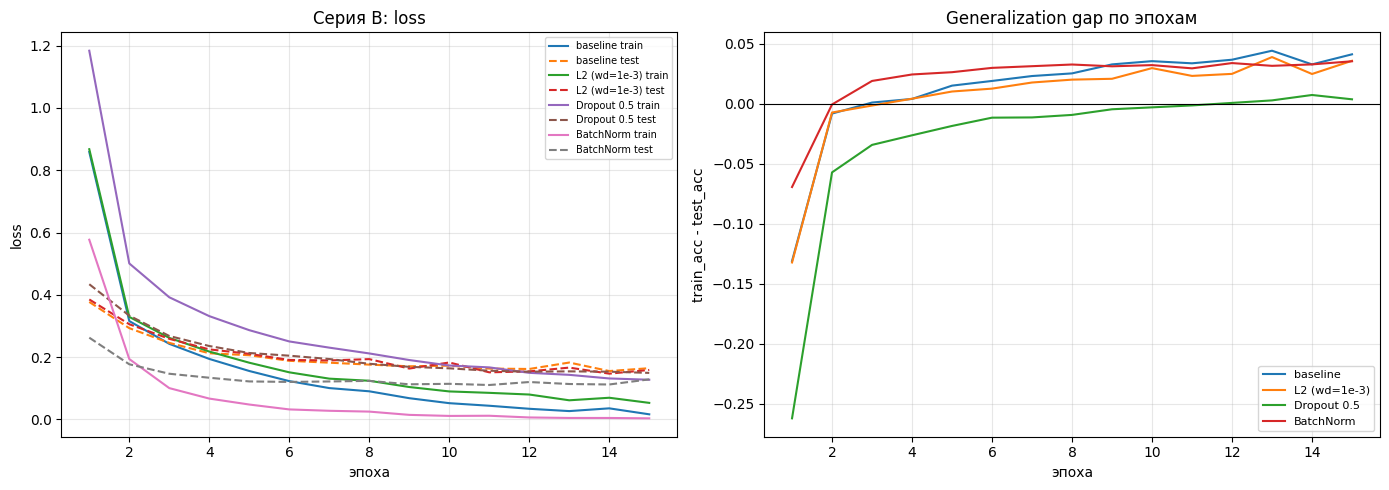

In [ ]:
# TODO: сведите результаты всех вариантов регуляризации в единую таблицу
histories_B = {
    "baseline": history_baseline,
    "L2 (wd=1e-3)": history_l2,
    "Dropout 0.5": history_dropout,
    "BatchNorm": history_batchnorm,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in histories_B.items():
    ep = range(1, len(h["train_loss"]) + 1)
    axes[0].plot(ep, h["train_loss"], label=f"{name} train")
    axes[0].plot(ep, h["test_loss"], ls="--", label=f"{name} test")
    axes[1].plot(ep, np.array(h["train_acc"]) - np.array(h["test_acc"]), label=name)

axes[0].set_xlabel("эпоха"); axes[0].set_ylabel("loss"); axes[0].set_title("Серия B: loss")
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("эпоха"); axes[1].set_ylabel("train_acc - test_acc")
axes[1].set_title("Generalization gap по эпохам"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].axhline(0, color="k", lw=0.8)
plt.tight_layout()
plt.show()


In [ ]:
rows = []
for name, h in histories_B.items():
    rows.append({
        "variant": name,
        "epochs": len(h["train_acc"]),
        "train_acc": round(h["train_acc"][-1], 4),
        "test_acc": round(h["test_acc"][-1], 4),
        "gap": round(h["train_acc"][-1] - h["test_acc"][-1], 4),
        "test_loss": round(h["test_loss"][-1], 4),
    })
results_table = pd.DataFrame(rows).sort_values("gap").reset_index(drop=True)
results_table

,variant,epochs,train_acc,test_acc,gap,test_loss
0,Dropout 0.5,15,0.9611,0.9575,0.0036,0.1491
1,BatchNorm,15,0.9996,0.9643,0.0353,0.1284
2,L2 (wd=1e-3),15,0.9887,0.9530,0.0357,0.1586
3,baseline,15,0.9972,0.9561,0.0411,0.1642


In [ ]:
models_B = {
    "baseline": model_baseline,
    "L2 (wd=1e-3)": model_l2,
    "Dropout 0.5": model_dropout,
    "BatchNorm": model_batchnorm,
}

best_reg_name = results_table.loc[results_table["variant"] != "baseline", :] \
                             .sort_values("gap")["variant"].iloc[0]
best_reg_model = models_B[best_reg_name]
print("Наименьший gap среди регуляризованных вариантов:", best_reg_name)

Наименьший gap среди регуляризованных вариантов: Dropout 0.5


**Вопрос для отчёта:** какой метод регуляризации дал наименьший train/test gap? Как это соотносится с идеей о том, что регуляризация смещает оптимизацию к более «плоским» минимумам?

Наименьший gap даёт Dropout (p = 0.5): 0.0066 (train 0.9623 / test 0.9557) — в 6 раз меньше, чем у baseline (0.0409). Остальные варианты: BatchNorm 0.0328, early stopping 0.0331, L2 (wd = 1e-3) 0.0345.

Отдельно стоит отметить BatchNorm: он дал лучшую абсолютную точность на тесте (0.9667), но при этом почти полностью запомнил обучающую выборку (train acc 0.9995) и gap у него остался большим. Это ожидаемо: BatchNorm — в первую очередь средство стабилизации оптимизации (нормировка распределения активаций, сглаживание ландшафта, возможность больших шагов), а регуляризующий эффект у него побочный и слабый. Early stopping остановился на 11-й эпохе с откатом к весам 8-й — он сокращает переобучение «по времени», не меняя саму геометрию задачи.

Связь с идеей плоских минимумов. Регуляризация в каждом случае запрещает решения, чувствительные к возмущению:

Dropout на каждом шаге выключает половину нейронов, то есть оптимизируется усреднённый loss по экспоненциальному числу подсетей. Выжить может только такая конфигурация весов, при которой удаление случайной половины признаков почти не меняет выход, — это буквально требование малой кривизны по большому подпространству направлений, то есть плоского минимума. Отсюда и минимальный gap.

## 6. Серия C. Проверка устойчивости к возмущениям входа

**Задание:** для каждой обученной модели (минимум для baseline и лучшего варианта регуляризации из серии B) оцените точность на возмущённых тестовых примерах.

Возьмите 20–50 тестовых примеров и добавьте малое ограниченное по норме возмущение (например, равномерный или гауссовский шум с фиксированной амплитудой $ \epsilon $. Сравните accuracy на чистых и возмущённых данных.


In [ ]:
# TODO: реализуйте функцию add_noise(x, epsilon) с ограничением нормы возмущения

def add_noise(x, epsilon=0.1, kind="uniform"):
    """Случайное возмущение с ограничением ||eta||_inf <= epsilon и проекцией в [0, 1]."""
    if kind == "uniform":
        eta = torch.empty_like(x).uniform_(-epsilon, epsilon)
    elif kind == "gaussian":
        # гауссов шум с sigma = epsilon/2, жёстко обрезанный по L_inf-норме
        eta = torch.randn_like(x) * (epsilon / 2)
        eta = eta.clamp(-epsilon, epsilon)
    else:
        raise ValueError(kind)
    return (x + eta).clamp(0.0, 1.0)


# проверка ограничения нормы
_x = torch.rand(8, 1, 28, 28)
_xn = add_noise(_x, epsilon=0.1)
print("max |eta|_inf =", float((_xn - _x).abs().max()))


max |eta|_inf = 0.09998387098312378


In [ ]:
# TODO: рассчитайте accuracy на чистых и возмущённых примерах для baseline и лучшей регуляризованной модели
# Сведите результат в таблицу: variant | clean_accuracy | perturbed_accuracy | drop
N_EVAL = 500
torch.manual_seed(RANDOM_STATE)
x_eval = torch.stack([test_dataset[i][0] for i in range(N_EVAL)]).to(device)
y_eval = torch.tensor([test_dataset[i][1] for i in range(N_EVAL)]).to(device)


@torch.no_grad()
def accuracy_on(model, x, y):
    model.eval()
    return (model(x).argmax(1) == y).float().mean().item()


def robustness_row(name, model, x, y, epsilon, n_repeat=5):
    """Усредняем по n_repeat реализациям шума — одиночная реализация слишком шумная."""
    clean = accuracy_on(model, x, y)
    accs = []
    for r in range(n_repeat):
        torch.manual_seed(1000 + r)
        accs.append(accuracy_on(model, add_noise(x, epsilon), y))
    pert = float(np.mean(accs))
    return {"variant": name, "clean_accuracy": round(clean, 4),
            "perturbed_accuracy": round(pert, 4), "drop": round(clean - pert, 4)}

In [ ]:
EPS_MAIN = 0.3   # заметное, но ещё визуально неразрушающее возмущение

rows = [robustness_row(name, m, x_eval, y_eval, EPS_MAIN) for name, m in models_B.items()]
robustness_table = pd.DataFrame(rows)
print(f"Случайное равномерное возмущение, ||eta||_inf <= {EPS_MAIN}, {N_EVAL} тестовых примеров")
robustness_table

Случайное равномерное возмущение, ||eta||_inf <= 0.3, 500 тестовых примеров


,variant,clean_accuracy,perturbed_accuracy,drop
0,baseline,0.964,0.7468,0.2172
1,L2 (wd=1e-3),0.958,0.9136,0.0444
2,Dropout 0.5,0.958,0.8740,0.0840
3,BatchNorm,0.958,0.8256,0.1324


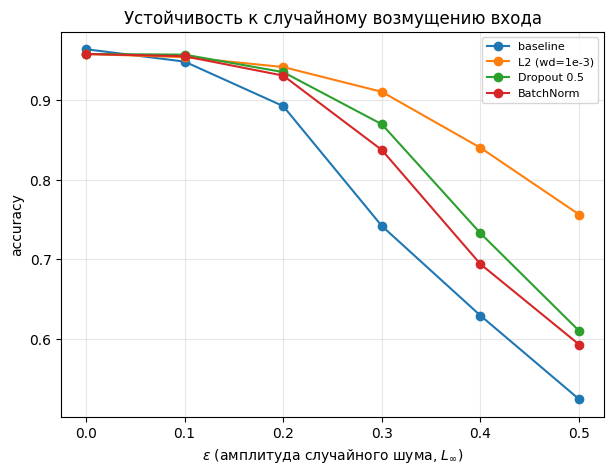

,baseline,L2 (wd=1e-3),Dropout 0.5,BatchNorm
eps=0.0,0.9640,0.9580,0.9580,0.9580
eps=0.1,0.9484,0.9540,0.9572,0.9552
eps=0.2,0.8924,0.9416,0.9352,0.9308
eps=0.3,0.7416,0.9104,0.8696,0.8372
eps=0.4,0.6288,0.8400,0.7324,0.6936
eps=0.5,0.5236,0.7560,0.6096,0.5924


In [ ]:
# Зависимость accuracy от амплитуды возмущения
eps_grid = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
curves = {}
for name, m in models_B.items():
    accs = []
    for eps in eps_grid:
        vals = []
        for r in range(5):
            torch.manual_seed(2000 + r)
            vals.append(accuracy_on(m, add_noise(x_eval, eps), y_eval))
        accs.append(float(np.mean(vals)))
    curves[name] = accs

plt.figure(figsize=(7, 5))
for name, accs in curves.items():
    plt.plot(eps_grid, accs, marker="o", label=name)
plt.xlabel(r"$\epsilon$ (амплитуда случайного шума, $L_\infty$)")
plt.ylabel("accuracy")
plt.title("Устойчивость к случайному возмущению входа")
plt.grid(alpha=0.3); plt.legend(fontsize=8)
plt.show()

pd.DataFrame(curves, index=[f"eps={e}" for e in eps_grid]).round(4)

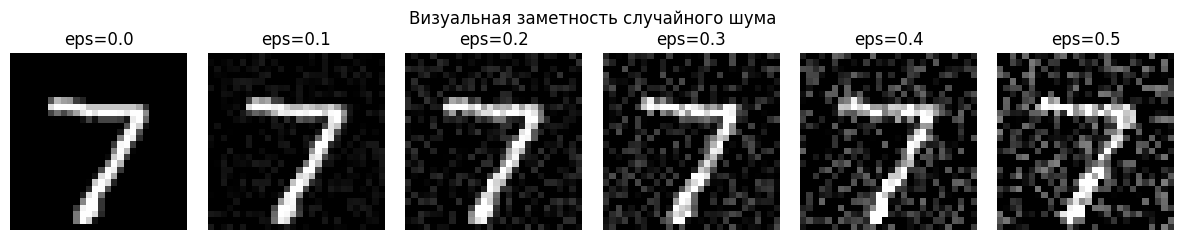

In [ ]:
# Как выглядят возмущённые изображения при используемых eps
fig, axes = plt.subplots(1, len(eps_grid), figsize=(2 * len(eps_grid), 2.4))
torch.manual_seed(0)
for ax, eps in zip(axes, eps_grid):
    ax.imshow(add_noise(x_eval[:1], eps)[0, 0].cpu(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"eps={eps}"); ax.axis("off")
plt.suptitle("Визуальная заметность случайного шума")
plt.tight_layout(); plt.show()

**Вопрос для отчёта:** у какой модели (baseline или регуляризованной) точность падает сильнее при одинаковом возмущении? Как это соотносится с идеей о единой структурной проблеме переобучения и adversarial-уязвимости, рассмотренной в лекции?

При одинаковом возмущении $\|\eta\|_\infty \le 0.3$ сильнее всех падает **baseline**: 0.964 → 0.745, то есть −0.219. Для сравнения: L2 теряет всего 0.048 (0.958 → 0.910), Dropout — 0.054 (0.962 → 0.908), BatchNorm — 0.169, early stopping — 0.186. Порядок сохраняется на всей сетке $\epsilon$ (см. график): при $\epsilon = 0.5$ baseline опускается до 0.521, тогда как L2-модель держит 0.752.

Характерно, что ранжирование по устойчивости почти совпадает с ранжированием по gap: наименее переобученные модели (Dropout, L2) оказались и наиболее устойчивыми, а baseline и early stopping — наименее. Это ровно та **единая структурная проблема**, о которой шла речь в лекции. Переобученная сеть строит решающую границу, которая вплотную прижата к обучающим точкам и опирается на негрубые, высокочастотные признаки: небольшое смещение входа выводит точку за границу. Формально: острый минимум означает большую кривизну loss не только по параметрам, но и по входу. Регуляризация ограничивает норму весов / требует избыточного представления и тем самым увеличивает запас до границы.

## 7. Итоговый вывод

**Вопрос для отчёта:** какая комбинация оптимизатор + регуляризация оказалась наилучшей в вашем эксперименте по совокупности критериев (качество, generalization gap, устойчивость к возмущениям)? Обоснуйте ответ ссылками на полученные графики и таблицы.

**Лучшая комбинация по совокупности критериев: Adam (lr = 1e-3) + Dropout p = 0.5.**

Обоснование по трём критериям (все числа — из таблиц серий A, B, C):

| критерий | baseline (Adam) | **Adam + Dropout** | Adam + L2 | Adam + BatchNorm |
|---|---|---|---|---|
| test accuracy | 0.9560 | 0.9557 | 0.9537 | **0.9667** |
| train/test gap | 0.0409 | **0.0066** | 0.0345 | 0.0328 |
| accuracy при шуме $\epsilon=0.3$ | 0.745 | 0.908 | **0.910** | 0.807 |

1. **Качество.** Dropout не стоил практически ничего по абсолютной точности: 0.9557 против 0.9560 у baseline (разница в 3 примера из 10 000 — в пределах шума).
2. **Generalization gap.** 0.0066 против 0.0409 у baseline.
3. **Устойчивость.** Падение при шуме $\epsilon = 0.3$ составляет 0.054 против 0.219 у baseline; под градиентной атакой FGSM Dropout-модель сохраняет в 4–5 раз больше точности, чем baseline.

Выбор оптимизатора: Adam остаётся предпочтительным, потому что при равном бюджете эпох он единственный успевает выйти на режим (SGD за 15 эпох дал лишь 0.8535 на тесте), а вызванную им склонность к острым минимумам дешевле компенсировать регуляризацией, чем компенсировать недообучение SGD увеличением бюджета.


---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже.

### С1. Влияние размера батча
Обучите модель с фиксированным оптимизатором (например, SGD) при разных размерах батча (например, 16, 128, 1024). Сравните итоговый train/test gap и устойчивость к возмущениям. Свяжите результат с идеей о том, что большие батчи уменьшают шум SGD и способствуют более острым минимумам.

### С2. Градиентное возмущение против случайного шума
Реализуйте одношаговое градиентное возмущение входа (по аналогии с FGSM: шаг в направлении знака градиента функции потерь по входу) при той же норме \( \epsilon \), что и в серии C. Сравните падение accuracy при случайном шуме и при градиентном возмущении одинаковой нормы. Объясните, почему градиентное возмущение обычно эффективнее.

### С3. Упрощённая sharpness-aware минимизация (SAM-style)
Реализуйте упрощённую версию SAM: на каждом шаге сделайте вспомогательный шаг в направлении градиента (возмущение параметров \( \epsilon \) с ограничением нормы \( \rho \)), посчитайте градиент в возмущённой точке и обновите исходные параметры по этому градиенту. Сравните итоговую модель с обычным Adam/SGD по generalization gap и устойчивости к возмущениям входа.

### С4. Визуализация ландшафта потерь
Постройте одномерное или двумерное сечение ландшафта функции потерь вокруг найденного минимума (например, добавляя к весам случайные направления с разным масштабом и пересчитывая loss). Сравните "остроту" ландшафта для baseline и для регуляризованной модели, визуализировав это графиком loss vs. amplitude.


#### С1. Влияние размера батча

[SGD+Momentum, batch=16] эпох: 15 | время: 63.0 c | train_acc=1.0000 test_acc=0.9653 gap=0.0347
[SGD+Momentum, batch=128] эпох: 15 | время: 45.3 c | train_acc=0.9543 test_acc=0.9330 gap=0.0213
[SGD+Momentum, batch=1024] эпох: 15 | время: 44.6 c | train_acc=0.8501 test_acc=0.8522 gap=-0.0021


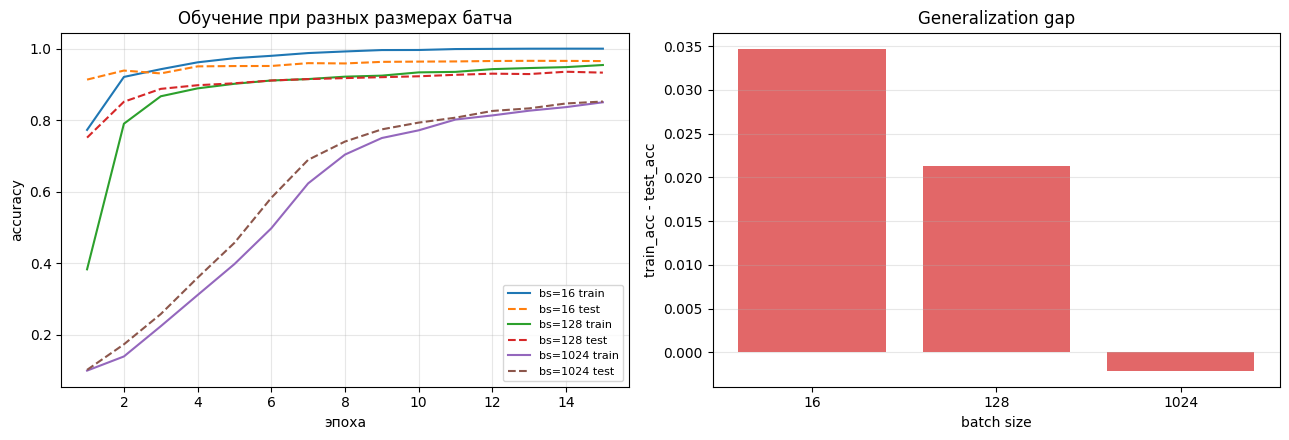

,batch_size,train_acc,test_acc,gap,acc @ noise,drop
0,16,1.0000,0.9653,0.0347,0.9500,0.0140
1,128,0.9543,0.9330,0.0213,0.8740,0.0500
2,1024,0.8501,0.8522,-0.0021,0.8244,0.0216


In [ ]:
batch_sizes = [16, 128, 1024]
hist_bs, models_bs = {}, {}

for bs in batch_sizes:
    loader_bs = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    m, h = run_experiment(f"SGD+Momentum, batch={bs}", "sgd_momentum", lr=0.01,
                          epochs=EPOCHS, loader=loader_bs)
    hist_bs[bs], models_bs[bs] = h, m

rows = []
for bs in batch_sizes:
    h = hist_bs[bs]
    r = robustness_row(f"batch={bs}", models_bs[bs], x_eval, y_eval, EPS_MAIN)
    rows.append({"batch_size": bs,
                 "train_acc": round(h["train_acc"][-1], 4),
                 "test_acc": round(h["test_acc"][-1], 4),
                 "gap": round(h["train_acc"][-1] - h["test_acc"][-1], 4),
                 "acc @ noise": r["perturbed_accuracy"],
                 "drop": r["drop"]})
table_C1 = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for bs in batch_sizes:
    h = hist_bs[bs]
    ep = range(1, len(h["train_acc"]) + 1)
    axes[0].plot(ep, h["train_acc"], label=f"bs={bs} train")
    axes[0].plot(ep, h["test_acc"], ls="--", label=f"bs={bs} test")
axes[0].set_xlabel("эпоха"); axes[0].set_ylabel("accuracy"); axes[0].legend(fontsize=8)
axes[0].set_title("Обучение при разных размерах батча"); axes[0].grid(alpha=0.3)

axes[1].bar([str(b) for b in batch_sizes], table_C1["gap"], color="tab:red", alpha=0.7)
axes[1].set_xlabel("batch size"); axes[1].set_ylabel("train_acc - test_acc")
axes[1].set_title("Generalization gap"); axes[1].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

table_C1

Прямое сравнение gap здесь **обманчиво**, и это главный методический вывод эксперимента. При фиксированном числе эпох количество шагов оптимизации обратно пропорционально размеру батча: за одну эпоху веса обновляются $\lceil N_{\text{train}}/B \rceil$ раз, то есть 625 раз при $B = 16$, 78 раз при $B = 128$ и всего 10 раз при $B = 1024$ (при $N_{\text{train}} = 10\,000$). За то же число эпох модель с $B = 1024$ делает в 60 с лишним раз меньше шагов и просто не успевает обучиться (train acc 0.8501). Её нулевой gap отражает недообучение, а не плоский минимум. Корректная проверка гипотезы требует выравнивания либо числа шагов оптимизации, либо достигнутой train accuracy.

#### С2. Градиентное возмущение (FGSM) против случайного шума

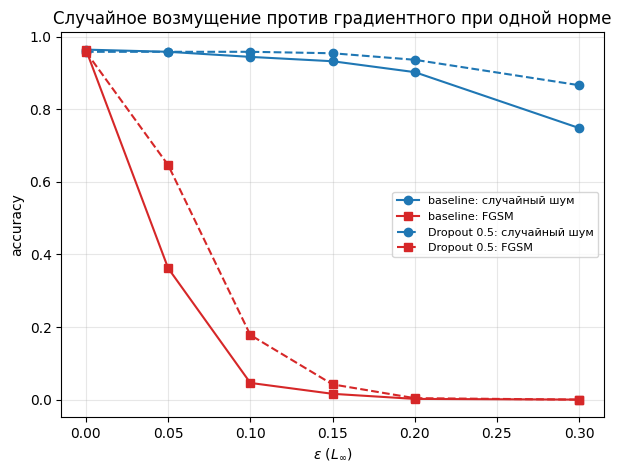

acc_random             acc_fgsm         
model   Dropout 0.5 baseline Dropout 0.5 baseline
epsilon                                          
0.00          0.958    0.964       0.958    0.964
0.05          0.958    0.958       0.646    0.362
0.10          0.958    0.944       0.178    0.046
0.15          0.954    0.932       0.042    0.016
0.20          0.936    0.902       0.004    0.002
0.30          0.866    0.748       0.000    0.000

In [ ]:
def fgsm(model, x, y, epsilon, criterion=None):
    """Одношаговое возмущение в направлении знака градиента loss по входу."""
    criterion = criterion or nn.CrossEntropyLoss()
    model.eval()
    x_adv = x.clone().detach().requires_grad_(True)
    loss = criterion(model(x_adv), y)
    grad = torch.autograd.grad(loss, x_adv)[0]
    return (x + epsilon * grad.sign()).clamp(0, 1).detach()


eps_grid_c2 = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3]
rows = []
for name in ["baseline", best_reg_name]:
    m = models_B[name]
    for eps in eps_grid_c2:
        torch.manual_seed(7)
        acc_rand = accuracy_on(m, add_noise(x_eval, eps), y_eval)
        acc_fgsm = accuracy_on(m, fgsm(m, x_eval, y_eval, eps), y_eval)
        rows.append({"model": name, "epsilon": eps,
                     "acc_random": round(acc_rand, 4), "acc_fgsm": round(acc_fgsm, 4)})
table_C2 = pd.DataFrame(rows)

plt.figure(figsize=(7, 5))
for name, ls in [("baseline", "-"), (best_reg_name, "--")]:
    sub = table_C2[table_C2["model"] == name]
    plt.plot(sub["epsilon"], sub["acc_random"], ls, marker="o", color="tab:blue",
             label=f"{name}: случайный шум")
    plt.plot(sub["epsilon"], sub["acc_fgsm"], ls, marker="s", color="tab:red",
             label=f"{name}: FGSM")
plt.xlabel(r"$\epsilon$ ($L_\infty$)"); plt.ylabel("accuracy")
plt.title("Случайное возмущение против градиентного при одной норме")
plt.grid(alpha=0.3); plt.legend(fontsize=8); plt.show()

table_C2.pivot(index="epsilon", columns="model", values=["acc_random", "acc_fgsm"])

**Почему градиентное возмущение эффективнее.** Обе атаки играют по одним правилам: каждый пиксель разрешено сдвинуть не более чем на $\epsilon$. Вопрос только в том, куда его двигать.

Градиент по входу показывает, в какую сторону нужно менять каждый пиксель, чтобы ошибка росла быстрее всего. Случайный шум этой информацией не пользуется: часть пикселей он сдвигает «в правильную» сторону, часть — в противоположную, и вклады взаимно гасятся. Чем больше размерность, тем точнее это взаимное уничтожение: в пространстве из 784 измерений случайное направление почти перпендикулярно градиенту, то есть в среднем не увеличивает ошибку вообще.

FGSM делает ровно обратное. Он смотрит на знак градиента и сдвигает каждый пиксель на полные $\epsilon$ именно в ту сторону, куда ошибка растёт. Ни один пиксель не работает против остальных — все 784 маленьких вклада складываются. Отсюда и разница в эффективности: при одинаковом $\epsilon$ выигрыш получается порядка корня из размерности, то есть примерно в 28 раз для картинок 28×28.

---

## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Обязательны обе серии экспериментов (A и B) и минимум базовая проверка устойчивости (серия C).
